First 5 Rows:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           Fa

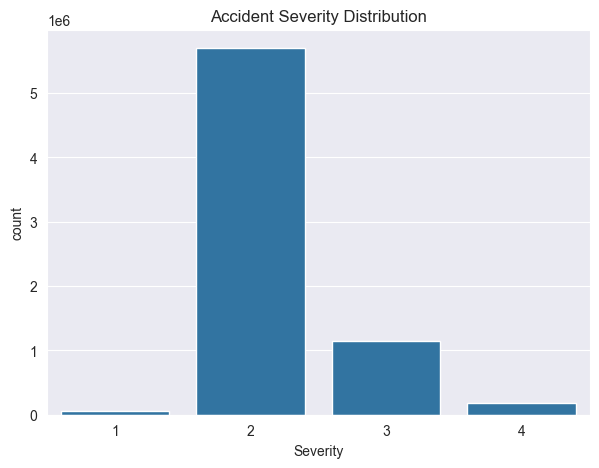

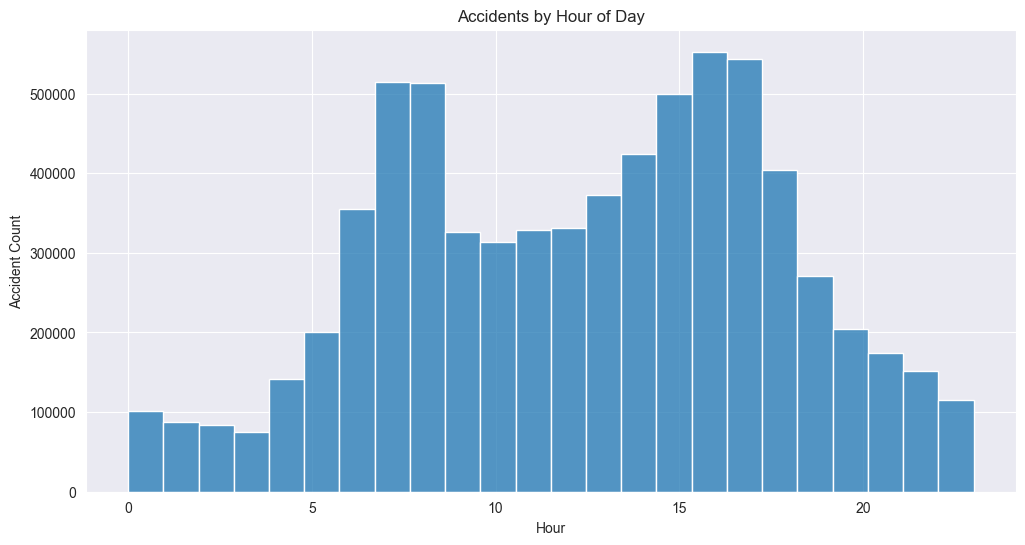

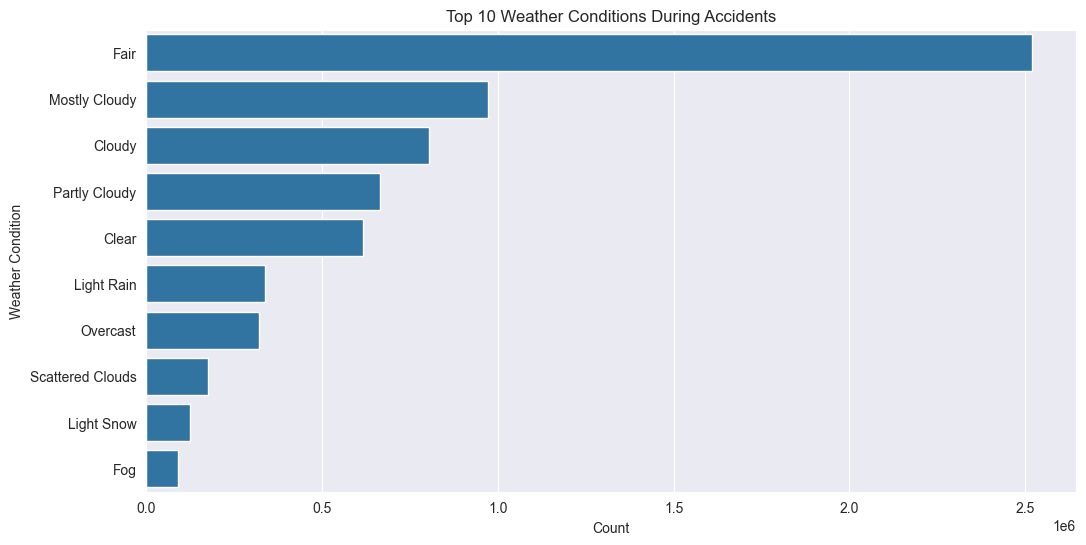

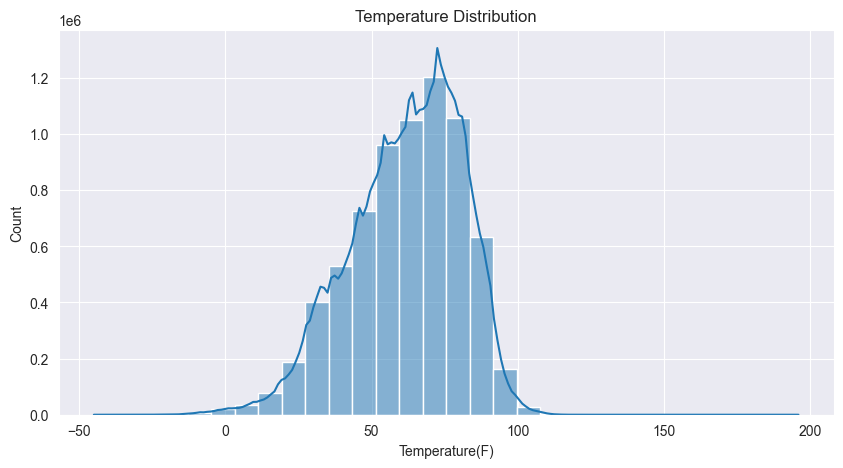

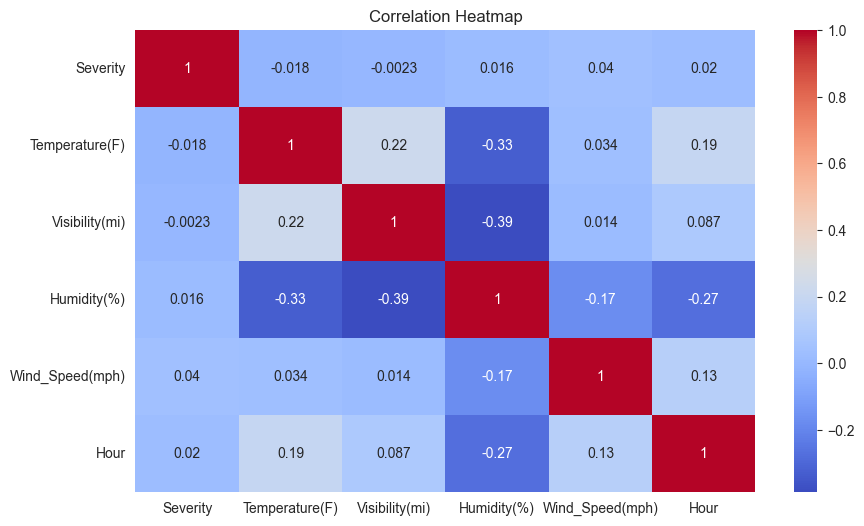

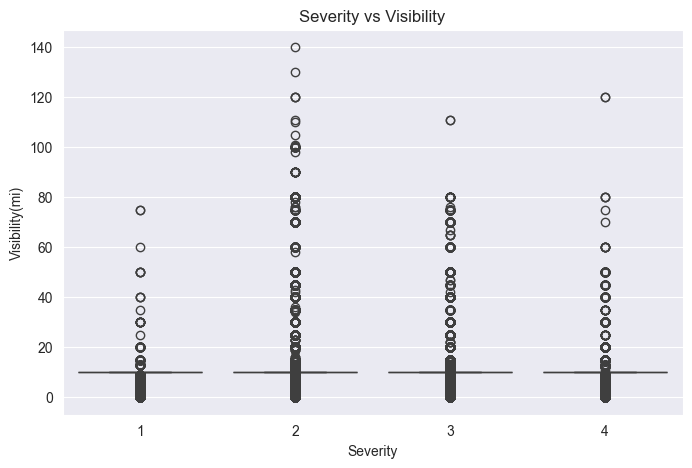


========== Insights ==========
1. Accident frequency varies throughout the day.
2. Certain weather conditions are linked with more accidents.
3. Visibility and weather impact accident severity.
4. Most accidents occur during high traffic hours.

Task 4 Completed Successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')


df = pd.read_csv(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Data\US_Accidents_March23.csv')

print("First 5 Rows:")
print(df.head())


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())


columns = [
    'Severity',
    'Start_Time',
    'Temperature(F)',
    'Weather_Condition',
    'Visibility(mi)',
    'Humidity(%)',
    'Wind_Speed(mph)'
]

df = df[columns]


df.dropna(inplace=True)

print("\nMissing Values Removed Successfully!")


df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='ISO8601')

df['Hour'] = df['Start_Time'].dt.hour

plt.figure(figsize=(7,5))

sns.countplot(x='Severity', data=df)

plt.title('Accident Severity Distribution')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\severity_distribution.png')

plt.show()

plt.figure(figsize=(12,6))

sns.histplot(df['Hour'], bins=24)

plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Accident Count')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\accidents_by_hour.png')

plt.show()

top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Count')
plt.ylabel('Weather Condition')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\weather_conditions.png')

plt.show()

plt.figure(figsize=(10,5))

sns.histplot(df['Temperature(F)'], bins=30, kde=True)

plt.title('Temperature Distribution')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\temperature_distribution.png')

plt.show()

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\correlation_heatmap.png')

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Severity',
    y='Visibility(mi)',
    data=df
)

plt.title('Severity vs Visibility')

plt.savefig(r'C:\Users\yashw\OneDrive\Desktop\Projects\SCT DS 4\Image\severity_vs_visibility.png')

plt.show()

print("\n========== Insights ==========")

print("1. Accident frequency varies throughout the day.")
print("2. Certain weather conditions are linked with more accidents.")
print("3. Visibility and weather impact accident severity.")
print("4. Most accidents occur during high traffic hours.")

print("\nTask 4 Completed Successfully!")